# Multimodal Predictions Analysis

Analyze and display multimodal prediction metrics from experiments. Pass an experiment dict with type, name, and experiment_name, and view the analysis metrics without saving any results.


In [1]:
from typing import Any, Dict, List, Tuple

import os
import numpy as np
import torch
import yaml
from omegaconf import DictConfig, OmegaConf

# Setup root directory for the project
import rootutils
root_dir = rootutils.find_root(search_from=os.path.dirname(os.getcwd()), indicator=".project-root")
rootutils.setup_root(root_dir, indicator=".project-root", pythonpath=True)

PosixPath('/home/fsoto/Documents/SSLPeriodicLCs')

In [2]:
from typing import Any, Dict, List, Tuple

import hydra
import rootutils
from lightning import LightningDataModule, LightningModule, Trainer
from omegaconf import DictConfig, OmegaConf
import glob
import os
import numpy as np
import torch
import yaml

# Set environment variables and precision
os.environ['HYDRA_FULL_ERROR'] = '1'
torch.set_float32_matmul_precision('highest')

# Setup root directory for the project
root_dir = rootutils.find_root(search_from=os.path.dirname(os.getcwd()), indicator=".project-root")
rootutils.setup_root(root_dir, indicator=".project-root", pythonpath=True)

from src.utils import (
    RankedLogger,
    extras,
    instantiate_loggers,
    log_hyperparameters,
    task_wrapper,
)

In [3]:
def mean_logits_per_oid(oids,logits,labels):
    """Mean logits per object id.

    :param dataset: Dataset to use.
    :param all_idx: All idxs.
    :param all_logits: All logits.
    :return: Mean logits per object id.
    """

    #from oids ids by taking the part before _ 
    list_oids = []
    for oid in oids:
        list_oids.append(oid.decode('utf-8').split('_')[0])

    list_oids = np.array(list_oids)
    #create a dictionary with oids,logits,labels
    dict_logits = {}
    for i in range(len(list_oids)):
        if list_oids[i] not in dict_logits:
            dict_logits[list_oids[i]] = {'logits': [], 'labels': []}
        dict_logits[list_oids[i]]['logits'].append(logits[i])
        dict_logits[list_oids[i]]['labels'].append(labels[i])
    #mean logits and labels
    for key in dict_logits:
        dict_logits[key]['logits'] = np.argmax(np.mean(np.array(dict_logits[key]['logits']), axis=0))
        dict_logits[key]['labels'] = np.mean(np.array(dict_logits[key]['labels']), axis=0)
    #create a dictionary with oids,logits,labels
    return dict_logits

    

In [4]:
def analyze_multimodal_predictions(targets, logits_lcs, logits_feat, logits_mean=None):
    """Analyze prediction correctness for LC and Feature modalities.

    For each sample, determines if the model predicts correctly for LC only,
    Feature only, both modalities, or neither.

    :param targets: Ground truth labels (N,) array
    :param logits_lcs: Predicted logits for LC modality (N, num_classes) array
    :param logits_feat: Predicted logits for Feature modality (N, num_classes) array
    :param logits_mean: Predicted logits for mean of LC and Feat (N, num_classes) array
    :return: Dictionary with analysis metrics and per-sample predictions
    """
    from sklearn.metrics import f1_score

    if logits_lcs is None or logits_feat is None:
        print("Error: Both logits_lcs and logits_feat must be provided")
        return None

    preds_lcs = np.argmax(logits_lcs, axis=1)
    preds_feat = np.argmax(logits_feat, axis=1)
    preds_mean = np.argmax(logits_mean, axis=1) if logits_mean is not None else None

    correct_lcs = preds_lcs == targets
    correct_feat = preds_feat == targets
    correct_mean = preds_mean == targets if preds_mean is not None else None

    both_correct = correct_lcs & correct_feat
    lcs_only = correct_lcs & ~correct_feat
    feat_only = ~correct_lcs & correct_feat
    neither_correct = ~correct_lcs & ~correct_feat

    metrics = {
        "total_samples": len(targets),
        "both_correct": {
            "count": np.sum(both_correct),
            "percentage": 100 * np.sum(both_correct) / len(targets),
        },
        "lcs_only_correct": {
            "count": np.sum(lcs_only),
            "percentage": 100 * np.sum(lcs_only) / len(targets),
        },
        "feat_only_correct": {
            "count": np.sum(feat_only),
            "percentage": 100 * np.sum(feat_only) / len(targets),
        },
        "neither_correct": {
            "count": np.sum(neither_correct),
            "percentage": 100 * np.sum(neither_correct) / len(targets),
        },
        "lcs_accuracy": 100 * np.sum(correct_lcs) / len(targets),
        "feat_accuracy": 100 * np.sum(correct_feat) / len(targets),
        "lcs_f1": f1_score(targets, preds_lcs, average="weighted", zero_division=0),
        "feat_f1": f1_score(targets, preds_feat, average="weighted", zero_division=0),
    }

    if preds_mean is not None:
        metrics["mean_accuracy"] = 100 * np.sum(correct_mean) / len(targets)
        metrics["mean_f1"] = f1_score(targets, preds_mean, average="weighted", zero_division=0)

    predictions = {
        "targets": targets,
        "preds_lcs": preds_lcs,
        "preds_feat": preds_feat,
        "preds_mean": preds_mean,
        "correct_lcs": correct_lcs,
        "correct_feat": correct_feat,
        "correct_mean": correct_mean,
        "category": np.array([
            "both_correct" if b else "lcs_only" if l else "feat_only" if f else "neither_correct"
            for b, l, f in zip(both_correct, lcs_only, feat_only)
        ]),
    }

    return {"metrics": metrics, "predictions": predictions}


def print_multimodal_analysis(analysis_result, title="Multimodal Prediction Analysis", show_plot=True):
    """Print formatted multimodal analysis results and optional stacked bar plot."""
    import matplotlib.pyplot as plt

    if analysis_result is None:
        return None

    metrics = analysis_result["metrics"]

    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print(f"Total Samples: {metrics['total_samples']}")
    print(f"\n{'-'*60}")
    print("OVERALL ACCURACY")
    print(f"{'-'*60}")
    print(f"LC Modality Accuracy:       {metrics['lcs_accuracy']:.2f}%")
    print(f"Feature Modality Accuracy:  {metrics['feat_accuracy']:.2f}%")
    if "mean_accuracy" in metrics:
        print(f"Mean Logits Accuracy:       {metrics['mean_accuracy']:.2f}%")
    print(f"\n{'-'*60}")
    print("F1 SCORES (Weighted)")
    print(f"{'-'*60}")
    print(f"LC Modality F1:       {metrics['lcs_f1']:.4f}")
    print(f"Feature Modality F1:  {metrics['feat_f1']:.4f}")
    if "mean_f1" in metrics:
        print(f"Mean Logits F1:       {metrics['mean_f1']:.4f}")
    print(f"\n{'-'*60}")
    print("AGREEMENT ANALYSIS")
    print(f"{'-'*60}")
    print(
        f"Both Correct:     {metrics['both_correct']['count']:6d} ({metrics['both_correct']['percentage']:6.2f}%)"
    )
    print(
        f"LC Only Correct:  {metrics['lcs_only_correct']['count']:6d} ({metrics['lcs_only_correct']['percentage']:6.2f}%)"
    )
    print(
        f"Feat Only Correct:{metrics['feat_only_correct']['count']:6d} ({metrics['feat_only_correct']['percentage']:6.2f}%)"
    )
    print(
        f"Neither Correct:  {metrics['neither_correct']['count']:6d} ({metrics['neither_correct']['percentage']:6.2f}%)"
    )
    print(f"{'='*60}\n")

    labels = ["Both Correct", "LC Only", "Feat Only", "Neither"]
    metric_keys = ["both_correct", "lcs_only_correct", "feat_only_correct", "neither_correct"]
    percentages = [metrics[k]["percentage"] for k in metric_keys]
    counts = [metrics[k]["count"] for k in metric_keys]
    colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c"]

    if show_plot:
        fig, ax = plt.subplots(figsize=(8, 5))
        bottom = 0.0
        for label, pct, color in zip(labels, percentages, colors):
            ax.bar(title, pct, bottom=bottom, label=label, color=color, edgecolor="white", width=0.5)
            # Add percentage text in the middle of each segment
            if pct > 2:  # Only show label if segment is large enough
                ax.text(0, bottom + pct / 2, f"{pct:.1f}%", ha="center", va="center", fontweight="bold", color="white")
            bottom += pct
        ax.set_ylim(0, 100)
        ax.set_ylabel("Percentage of samples")
        ax.set_title(f"Agreement Analysis - {title}", fontsize=12, fontweight="bold")
        ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        plt.tight_layout()
        plt.show()

    return {"labels": labels, "percentages": percentages, "counts": counts}


def plot_agreement_stacked_bars(analysis_results, experiment_titles, use_percentages=True):
    """Plot stacked bar chart for agreement analysis across multiple experiments."""
    import matplotlib.pyplot as plt

    if not analysis_results:
        print("No analysis results to plot.")
        return

    labels = ["Both Correct", "LC Only", "Feat Only", "Neither"]
    metric_keys = ["both_correct", "lcs_only_correct", "feat_only_correct", "neither_correct"]
    colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c"]
    value_key = "percentage" if use_percentages else "count"

    bottoms = np.zeros(len(analysis_results), dtype=float)
    fig, ax = plt.subplots(figsize=(12, 6))

    for label, m_key, color in zip(labels, metric_keys, colors):
        values = [analysis["metrics"][m_key][value_key] for analysis in analysis_results]
        bars = ax.bar(experiment_titles, values, bottom=bottoms, label=label, color=color, edgecolor="white", width=0.6)
        
        # Add percentage text on each segment
        for i, (bar, val) in enumerate(zip(bars, values)):
            if val > 2:  # Only show label if segment is large enough
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2, bottoms[i] + height / 2,
                       f"{val:.1f}%", ha="center", va="center", fontweight="bold", color="white", fontsize=9)
        
        bottoms += np.array(values)

    ax.set_ylabel("Percentage of samples" if use_percentages else "Sample count")
    ax.set_ylim(0, 100 if use_percentages else bottoms.max() * 1.05)
    ax.set_title("Agreement Analysis Across Experiments", fontsize=12, fontweight="bold")
    ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


def analyze_oid_predictions(analysis_result, oids):
    """Extract OID-level prediction information from analysis results.
    
    :param analysis_result: Output from analyze_multimodal_predictions()
    :param oids: Array of OID identifiers (can be bytes or strings)
    :return: Dictionary with OID-level statistics and predictions
    """
    if analysis_result is None or oids is None:
        print("Error: analysis_result and oids must be provided")
        return None
    
    predictions = analysis_result["predictions"]
    
    # Convert oids to strings if they are bytes
    oid_strings = []
    for oid in oids:
        if isinstance(oid, bytes):
            oid_strings.append(oid.decode('utf-8'))
        else:
            oid_strings.append(str(oid))
    
    # Extract the base OID (part before underscore)
    base_oids = [oid.split('_')[0] for oid in oid_strings]
    
    oid_data = {}
    for i, base_oid in enumerate(base_oids):
        if base_oid not in oid_data:
            oid_data[base_oid] = {
                'targets': [],
                'preds_lcs': [],
                'preds_feat': [],
                'correct_lcs': [],
                'correct_feat': [],
                'category': [],
                'indices': []
            }
        
        oid_data[base_oid]['targets'].append(predictions['targets'][i])
        oid_data[base_oid]['preds_lcs'].append(predictions['preds_lcs'][i])
        oid_data[base_oid]['preds_feat'].append(predictions['preds_feat'][i])
        oid_data[base_oid]['correct_lcs'].append(predictions['correct_lcs'][i])
        oid_data[base_oid]['correct_feat'].append(predictions['correct_feat'][i])
        oid_data[base_oid]['category'].append(predictions['category'][i])
        oid_data[base_oid]['indices'].append(i)
    
    # Compute OID-level statistics
    oid_stats = {}
    for oid, data in oid_data.items():
        lc_correct = np.mean(data['correct_lcs'])
        feat_correct = np.mean(data['correct_feat'])
        both_correct = np.mean([lc and feat for lc, feat in zip(data['correct_lcs'], data['correct_feat'])])
        
        oid_stats[oid] = {
            'lc_accuracy': lc_correct,
            'feat_accuracy': feat_correct,
            'both_correct': both_correct,
            'n_samples': len(data['targets']),
            'data': data
        }
    
    return oid_stats


def get_incorrect_oids(oid_stats):
    """Get OIDs with incorrect predictions.
    
    :param oid_stats: Output from analyze_oid_predictions()
    :return: List of OIDs that have at least one incorrect prediction
    """
    incorrect_oids = []
    for oid, stats in oid_stats.items():
        # OID is incorrect if both modalities failed on at least one sample
        if stats['both_correct'] < 1.0:
            incorrect_oids.append(oid)
    
    return sorted(incorrect_oids, key=lambda x: oid_stats[x]['both_correct'])


def print_oid_analysis(oid_stats, title="OID-Level Analysis"):
    """Print OID-level statistics.
    
    :param oid_stats: Output from analyze_oid_predictions()
    :param title: Title for the output
    """
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}")
    print(f"Total OIDs: {len(oid_stats)}")
    print(f"\n{'OID':<20} {'LC Acc':<10} {'Feat Acc':<10} {'Both Correct':<15} {'Samples':<10}")
    print(f"{'-'*80}")
    
    for oid, stats in sorted(oid_stats.items(), key=lambda x: x[1]['both_correct']):
        print(f"{oid:<20} {stats['lc_accuracy']:>8.2%}  {stats['feat_accuracy']:>8.2%}  {stats['both_correct']:>13.2%}  {stats['n_samples']:>8d}")
    
    print(f"{'='*80}\n")


In [5]:

def plot_light_curve_by_oid(oid, dataset, predictions_dict=None, title_suffix="", figsize=(12, 5)):
    """Plot light curve for a specific OID.
    
    :param oid: OID string to plot
    :param dataset: H5 dataset with 'brightness', 'e_brightness', 'time', 'mask', 
                    'mask_photometry', 'mask_detection', and 'SNID' keys
    :param predictions_dict: Optional dict with 'targets', 'preds_lcs', 'preds_feat', 'category'
                            to overlay prediction information
    :param title_suffix: Additional text to append to title
    :param figsize: Figure size tuple (width, height)
    """
    import matplotlib.pyplot as plt
    
    # Find the index for this OID in the dataset
    snid_list = dataset['SNID'][:]
    snid_strings = [s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in snid_list]
    
    # Find all indices matching this OID
    matching_indices = [i for i, snid in enumerate(snid_strings) if snid.startswith(oid + '_')]
    
    if not matching_indices:
        print(f"No samples found for OID: {oid}")
        return
    
    # If predictions provided, find an incorrect sample; otherwise pick first
    if predictions_dict is not None and 'category' in predictions_dict:
        # Find incorrect predictions for this OID
        for idx in matching_indices:
            if idx < len(predictions_dict['category']):
                category = predictions_dict['category'][idx]
                if category != 'both_correct':
                    break
        else:
            # If all are correct, use first
            idx = matching_indices[0]
    else:
        idx = matching_indices[0]
    
    # Extract data for this sample
    flux = dataset['brightness'][idx]
    flux_err = dataset['e_brightness'][idx]
    time = dataset['time'][idx]
    mask = dataset['mask'][idx]
    mask_photometry = dataset['mask_photometry'][idx]
    mask_detection = dataset['mask_detection'][idx]
    snid = snid_strings[idx]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define band colors
    g_color, r_color = '#2E8B57', '#DC143C'  # Forest green and crimson
    
    # Plot photometry points (larger stars)
    g_phot = mask_photometry[:, 0] == 1
    r_phot = mask_photometry[:, 1] == 1
    if np.sum(g_phot) > 0:
        ax.scatter(time[g_phot, 0], flux[g_phot, 0], marker='*', color=g_color, 
                  label='g-band photometry', s=200, zorder=5, edgecolors='black', linewidth=0.5)
    if np.sum(r_phot) > 0:
        ax.scatter(time[r_phot, 1], flux[r_phot, 1], marker='*', color=r_color, 
                  label='r-band photometry', s=200, zorder=5, edgecolors='black', linewidth=0.5)
    
    # Plot detection points (smaller circles)
    g_det = mask_detection[:, 0] == 1
    r_det = mask_detection[:, 1] == 1
    if np.sum(g_det) > 0:
        ax.scatter(time[g_det, 0], flux[g_det, 0], marker='o', color=g_color, 
                  label='g-band detection', s=50, alpha=0.6, zorder=4)
    if np.sum(r_det) > 0:
        ax.scatter(time[r_det, 1], flux[r_det, 1], marker='o', color=r_color, 
                  label='r-band detection', s=50, alpha=0.6, zorder=4)
    
    # Plot error bars
    g_band = mask[:, 0] == 1
    r_band = mask[:, 1] == 1
    if np.sum(g_band) > 0:
        ax.errorbar(time[g_band, 0], flux[g_band, 0], yerr=flux_err[g_band, 0], 
                   color=g_color, fmt='none', elinewidth=1, alpha=0.4, zorder=2)
    if np.sum(r_band) > 0:
        ax.errorbar(time[r_band, 1], flux[r_band, 1], yerr=flux_err[r_band, 1], 
                   color=r_color, fmt='none', elinewidth=1, alpha=0.4, zorder=2)
    
    # Add prediction information if available
    pred_text = ""
    if predictions_dict is not None and idx < len(predictions_dict.get('targets', [])):
        target = predictions_dict['targets'][idx]
        pred_lc = predictions_dict.get('preds_lcs', [None])[idx]
        pred_feat = predictions_dict.get('preds_feat', [None])[idx]
        category = predictions_dict.get('category', [''])[idx]
        
        pred_text = f"\nTrue: {target} | LC Pred: {pred_lc} | Feat Pred: {pred_feat} | {category}"
    
    # Labels and title
    ax.set_xlabel('Time (MJD)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Flux', fontsize=11, fontweight='bold')
    title = f'Light Curve - OID: {oid} (SNID: {snid}){title_suffix}'
    if pred_text:
        title += pred_text
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return idx

def plot_incorrect_lightcurves_interactive(dataset, predictions_dict, oids, category_filter='neither_correct', 
                                            plots_per_batch=9):
    """Plot light curves for incorrect predictions with interactive navigation.
    
    Creates an interactive widget with Previous/Next buttons to navigate through batches of light curves.
    
    :param dataset: H5 dataset with light curve data
    :param predictions_dict: Dict with 'targets', 'preds_lcs', 'preds_feat', 'category'
    :param oids: Array of OID values corresponding to predictions (can be None)
    :param category_filter: Type of incorrect prediction to show 
                            ('both_correct', 'lcs_only', 'feat_only', 'neither_correct')
    :param plots_per_batch: Number of light curves to display per batch
    """
    import matplotlib.pyplot as plt
    from ipywidgets import Button, HBox, HTML, Output
    from IPython.display import display
    
    # Check if oids is available
    if oids is None:
        print("Warning: OID information not available. Cannot plot light curves.")
        return
    
    # Find indices matching the category filter
    matching_indices = [i for i, cat in enumerate(predictions_dict['category']) 
                        if cat == category_filter]
    
    if not matching_indices:
        print(f"No samples found with category '{category_filter}'")
        return
    
    print(f"Found {len(matching_indices)} samples with category '{category_filter}'")
    
    # Prepare OID list for all matching indices - extract unique OIDs
    oid_to_indices = {}  # Map from OID to list of data indices
    for idx in matching_indices:
        if idx < len(oids):
            oid = oids[idx]
            # Handle numpy.bytes_ and bytes objects
            if hasattr(oid, 'decode'):
                oid = oid.decode('utf-8')
            else:
                oid = str(oid)
            
            # Extract base OID (part before underscore)
            oid = oid.split('_')[0]
            if oid not in oid_to_indices:
                oid_to_indices[oid] = []
            oid_to_indices[oid].append(idx)
    all_oids = list(oid_to_indices.keys())
    print(f"Found {len(all_oids)} unique OIDs")
    
    # Prepare dataset mapping - keep full SNID strings
    snid_list = dataset['SNID'][:]
    snid_strings = [s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in snid_list]

    # Create state for pagination
    state = {
        'current_batch': 0,
        'total_batches': (len(all_oids) + plots_per_batch - 1) // plots_per_batch
    }
    
    output = Output()
    status_label = HTML()
    
    def plot_batch(batch_idx):
        """Plot a batch of light curves."""
        with output:
            output.clear_output(wait=True)
            
            start_idx = batch_idx * plots_per_batch
            end_idx = min(start_idx + plots_per_batch, len(all_oids))
            batch_oids = all_oids[start_idx:end_idx]
            
            num_plots = len(batch_oids)
            ncols = min(3, num_plots)
            nrows = (num_plots + ncols - 1) // ncols
            
            fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
            if num_plots == 1:
                axes = [axes]
            else:
                axes = axes.flatten()
            
            # Plot each light curve in batch
            g_color, r_color = '#2E8B57', '#DC143C'
            
            for plot_idx, oid in enumerate(batch_oids):
                ax = axes[plot_idx]
                data_idx = oid_to_indices[oid][0]  # Use first occurrence
                
                # Find sample index in dataset - match OID at start of SNID
                matching_snid_indices = [i for i, snid in enumerate(snid_strings) 
                                        if snid==oid]
                if not matching_snid_indices:
                    ax.text(0.5, 0.5, f'OID {oid} not found in dataset', ha='center', va='center')
                    ax.set_title(f"OID: {oid} (NOT FOUND)", fontsize=10, fontweight='bold', color='red')
                    continue
                    
                sample_idx = matching_snid_indices[0]
                
                # Extract data
                flux = dataset['brightness'][sample_idx]
                flux_err = dataset['e_brightness'][sample_idx]
                time = dataset['time'][sample_idx]
                mask = dataset['mask'][sample_idx]
                mask_photometry = dataset['mask_photometry'][sample_idx]
                mask_detection = dataset['mask_detection'][sample_idx]
                period = dataset['extracted_feat_None'][sample_idx,83]
                #time = time %  period
                # Plot on current axis
                g_phot = mask_photometry[:, 0] == 1
                r_phot = mask_photometry[:, 1] == 1
                g_det = mask_detection[:, 0] == 1
                r_det = mask_detection[:, 1] == 1
                g_band = mask[:, 0] == 1
                r_band = mask[:, 1] == 1
                
                if np.sum(g_phot) > 0:
                    ax.scatter(time[g_phot, 0], flux[g_phot, 0], marker='*', color=g_color, s=5, zorder=5)
                if np.sum(r_phot) > 0:
                    ax.scatter(time[r_phot, 1], flux[r_phot, 1], marker='*', color=r_color, s=5, zorder=5)
                if np.sum(g_det) > 0:
                    ax.scatter(time[g_det, 0], flux[g_det, 0], marker='o', color=g_color, s=5, alpha=0.6, zorder=4)
                if np.sum(r_det) > 0:
                    ax.scatter(time[r_det, 1], flux[r_det, 1], marker='o', color=r_color, s=4, alpha=0.6, zorder=4)
                if np.sum(g_band) > 0:
                    ax.errorbar(time[g_band, 0], flux[g_band, 0], yerr=flux_err[g_band, 0], 
                                color=g_color, fmt='none', elinewidth=0.8, alpha=0.3, zorder=2)
                if np.sum(r_band) > 0:
                    ax.errorbar(time[r_band, 1], flux[r_band, 1], yerr=flux_err[r_band, 1], 
                                color=r_color, fmt='none', elinewidth=0.8, alpha=0.3, zorder=2)
                # Periodic class names (predictions are already in periodic label space 0-8)
                periodic_class_names = {
                    0: 'CEP',
                    1: 'DSCT', 
                    2: 'EA',
                    3: 'EB/EW',
                    4: 'LPV',
                    5: 'Periodic-Other',
                    6: 'RRLab',
                    7: 'RRLc',
                    8: 'RSCVn'
                }
                
                # Title with prediction info
                if data_idx < len(predictions_dict['targets']):
                    target = periodic_class_names.get(int(predictions_dict['targets'][data_idx]), 'Unknown')
                    pred_lc = periodic_class_names.get(int(predictions_dict['preds_lcs'][data_idx]), 'Unknown')
                    pred_feat = periodic_class_names.get(int(predictions_dict['preds_feat'][data_idx]), 'Unknown')

                    title = f"OID: {oid} \nTrue: {target} | LC: {pred_lc} | Feat: {pred_feat}"
                else:
                    title = f"OID: {oid}"
                    
                ax.set_title(title, fontsize=10, fontweight='bold')
                ax.set_xlabel('Time (MJD)', fontsize=9)
                ax.set_ylabel('Flux', fontsize=9)
                ax.grid(True, alpha=0.3, linestyle='--')
            
            # Hide unused subplots
            for idx in range(num_plots, len(axes)):
                axes[idx].axis('off')
            
            batch_info = f"OIDs {start_idx + 1}-{end_idx} of {len(all_oids)} ({category_filter.replace('_', ' ')})"
            fig.suptitle(batch_info, fontsize=14, fontweight='bold', y=1.00)
            plt.tight_layout()
            plt.show()
        
        # Update status label after plotting
        update_button_label()
    
    def on_next_clicked(b):
        """Handle next button click."""
        state['current_batch'] = (state['current_batch'] + 1) % state['total_batches']
        plot_batch(state['current_batch'])
    
    def on_prev_clicked(b):
        """Handle previous button click."""
        state['current_batch'] = (state['current_batch'] - 1) % state['total_batches']
        plot_batch(state['current_batch'])
    
    def update_button_label():
        """Update navigation buttons label."""
        batch_num = state['current_batch'] + 1
        total = state['total_batches']
        status_label.value = f"<b>Batch {batch_num} of {total}</b> | Total Unique OIDs: {len(all_oids)}"
    
    # Create buttons
    prev_button = Button(description='← Previous', button_style='info')
    next_button = Button(description='Next →', button_style='info')
    prev_button.on_click(on_prev_clicked)
    next_button.on_click(on_next_clicked)
    
    # Show navigation controls first
    nav_box = HBox([prev_button, status_label, next_button])
    display(nav_box)
    display(output)
    
    # Display initial batch (this will also update the label)
    plot_batch(0)

def plot_incorrect_lightcurves(dataset, predictions_dict, oids, category_filter='neither_correct', 
                               max_plots=9, figsize=(14, 4)):
    """Plot light curves for incorrect predictions.
    
    :param dataset: H5 dataset with light curve data
    :param predictions_dict: Dict with 'targets', 'preds_lcs', 'preds_feat', 'category'
    :param oids: Array of OID values corresponding to predictions (can be None)
    :param category_filter: Type of incorrect prediction to show 
                           ('both_correct', 'lcs_only', 'feat_only', 'neither_correct')
    :param max_plots: Maximum number of light curves to display
    :param figsize: Figure size for each subplot
    """
    import matplotlib.pyplot as plt
    
    # Check if oids is available
    if oids is None:
        print("Warning: OID information not available. Cannot plot light curves.")
        return
    
    # Find indices matching the category filter
    matching_indices = [i for i, cat in enumerate(predictions_dict['category']) 
                       if cat == category_filter]
    
    if not matching_indices:
        print(f"No samples found with category '{category_filter}'")
        return
    
    # Select random subset
    import random
    selected_indices = random.sample(matching_indices, min(max_plots, len(matching_indices)))
    
    # Get unique OIDs for selected indices
    selected_oids = []
    for idx in selected_indices:
        if idx < len(oids):
            oid = oids[idx]
            if isinstance(oid, bytes):
                oid = oid.decode('utf-8')
            oid = str(oid).split('_')[0]
            selected_oids.append(oid)
    
    # Create grid of subplots
    num_plots = len(selected_oids)
    ncols = min(3, num_plots)
    nrows = (num_plots + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Plot each light curve
    snid_list = dataset['SNID'][:]
    snid_strings = [s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in snid_list]
    
    for plot_idx, (oid, data_idx) in enumerate(zip(selected_oids, selected_indices)):
        ax = axes[plot_idx]
        
        # Find sample index in dataset
        matching_snid_indices = [i for i, snid in enumerate(snid_strings) 
                                if snid.startswith(oid + '_')]
        if not matching_snid_indices:
            continue
            
        sample_idx = matching_snid_indices[0]
        
        # Extract data
        flux = dataset['brightness'][sample_idx]
        flux_err = dataset['e_brightness'][sample_idx]
        time = dataset['time'][sample_idx]
        mask = dataset['mask'][sample_idx]
        mask_photometry = dataset['mask_photometry'][sample_idx]
        mask_detection = dataset['mask_detection'][sample_idx]
        
        # Plot on current axis
        g_color, r_color = '#2E8B57', '#DC143C'
        
        g_phot = mask_photometry[:, 0] == 1
        r_phot = mask_photometry[:, 1] == 1
        g_det = mask_detection[:, 0] == 1
        r_det = mask_detection[:, 1] == 1
        g_band = mask[:, 0] == 1
        r_band = mask[:, 1] == 1
        
        if np.sum(g_phot) > 0:
            ax.scatter(time[g_phot, 0], flux[g_phot, 0], marker='*', color=g_color, s=150, zorder=5)
        if np.sum(r_phot) > 0:
            ax.scatter(time[r_phot, 1], flux[r_phot, 1], marker='*', color=r_color, s=150, zorder=5)
        if np.sum(g_det) > 0:
            ax.scatter(time[g_det, 0], flux[g_det, 0], marker='o', color=g_color, s=40, alpha=0.6, zorder=4)
        if np.sum(r_det) > 0:
            ax.scatter(time[r_det, 1], flux[r_det, 1], marker='o', color=r_color, s=40, alpha=0.6, zorder=4)
        if np.sum(g_band) > 0:
            ax.errorbar(time[g_band, 0], flux[g_band, 0], yerr=flux_err[g_band, 0], 
                       color=g_color, fmt='none', elinewidth=0.8, alpha=0.3, zorder=2)
        if np.sum(r_band) > 0:
            ax.errorbar(time[r_band, 1], flux[r_band, 1], yerr=flux_err[r_band, 1], 
                       color=r_color, fmt='none', elinewidth=0.8, alpha=0.3, zorder=2)
        
        # Title with prediction info
        target = predictions_dict['targets'][data_idx]
        pred_lc = predictions_dict['preds_lcs'][data_idx]
        pred_feat = predictions_dict['preds_feat'][data_idx]
        
        title = f"OID: {oid}\nTrue: {target} | LC: {pred_lc} | Feat: {pred_feat}"
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (MJD)', fontsize=9)
        ax.set_ylabel('Flux', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
    
    # Hide unused subplots
    for idx in range(num_plots, len(axes)):
        axes[idx].axis('off')
    
    fig.suptitle(f'Light Curves - {category_filter.replace("_", " ")} (max {max_plots} shown)', 
                fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


## Multimodal Prediction Analysis

This section provides tools to analyze how well each modality (LC and Features) predicts correctly, individually and jointly.


In [6]:
def load_multimodal_predictions(exp_dict, split_idx=0):
    """
    Load predictions from checkpoints for LC and Feature modalities.

    :param exp_dict: Dictionary with 'type', 'name', 'experiment_name' keys
    :param split_idx: Index of the test split to evaluate on (default: 0)
    :return: Dictionary with keys 'targets', 'logits_lcs', 'logits_feat', 'logits_mean', 'oids'
    """
    import glob
    from lightning import LightningDataModule, LightningModule, Trainer
    
    type_name = exp_dict['type']
    experiment_name = exp_dict['name']
    experiment_path = f"../logs/{type_name}/{experiment_name}"
    
    # Find checkpoint files
    ckpt_files = glob.glob(os.path.join(experiment_path, "*", "checkpoints", "*.ckpt"))
    ckpt_files = [f for f in ckpt_files if not f.endswith('last.ckpt')]
    
    if not ckpt_files:
        print(f"No checkpoints found for {experiment_name}")
        return None
    
    # Filter and sort by split
    ckpt_files_clean = []
    data_splits = []
    for ckpt in ckpt_files:
        try:
            with open(os.path.join(os.path.dirname(os.path.dirname(ckpt)), ".hydra", "config.yaml"), 'r') as f:
                config_yaml = yaml.safe_load(f)
            data_percentage = config_yaml['data'].get('percentage', 1)
            if data_percentage >= 1:
                ckpt_files_clean.append(ckpt)
                data_splits.append(config_yaml['data'].get('split', 0))
        except:
            continue
    
    if not ckpt_files_clean:
        print(f"No valid checkpoints found for {experiment_name}")
        return None
    
    # Sort by split
    data_splits, ckpt_files_clean = zip(*sorted(zip(data_splits, ckpt_files_clean)))
    
    if split_idx >= len(ckpt_files_clean):
        print(f"Split {split_idx} not found. Available splits: 0-{len(ckpt_files_clean)-1}")
        return None
    
    # Load predictions from checkpoints
    multirun_config_path = os.path.join(experiment_path, "multirun.yaml")
    with open(multirun_config_path, "r") as f:
        cfg = yaml.safe_load(f)
    cfg = OmegaConf.create(cfg)
    OmegaConf.set_struct(cfg, False)
    
    try:
        trainer: Trainer = hydra.utils.instantiate(cfg.trainer)
    except Exception as e:
        # If instantiation fails due to Hydra interpolations, create a minimal trainer
        print(f"  Warning: Could not instantiate trainer from config ({type(e).__name__}), using minimal config")
        trainer = Trainer(accelerator="auto", devices="auto", enable_progress_bar=False, logger=False)
    
    trainer.logger = False
    cfg.data.test_set_type = 'test'
    cfg.data.normalize_tab = True
    cfg.data.return_snids = True
    
    # Load only the selected split
    ckpt = ckpt_files_clean[split_idx]
    split = data_splits[split_idx]
    print(f"  Loading split {split_idx} (data split: {split})...")
    
    cfg.data.split = split_idx % 5
    
    try:
        datamodule: LightningDataModule = hydra.utils.instantiate(cfg.data)
    except Exception as e:
        print(f"  Error instantiating datamodule: {e}")
        return None
    
    try:
        model: LightningModule = hydra.utils.instantiate(cfg.model)
    except Exception as e:
        print(f"  Error instantiating model: {e}")
        return None
    
    out = trainer.predict(model=model, dataloaders=datamodule, ckpt_path=ckpt)
    
    model_targets = []
    model_logits_lcs = []
    model_logits_feat = []
    model_oids = []
    
    for batch in out:
        model_targets.append(batch['targets'])
        if 'logits_lc' in batch and batch['logits_lc'] is not None:
            model_logits_lcs.append(batch['logits_lc'])
        if 'logits_feat' in batch and batch['logits_feat'] is not None:
            model_logits_feat.append(batch['logits_feat'])
        if 'oid' in batch and batch['oid'] is not None:
            model_oids.append(batch['oid'])
    targets = torch.cat(model_targets, axis=0).detach().cpu().numpy() if model_targets else None
    
    logits_lcs = None
    if model_logits_lcs:
        logits_lcs = torch.cat(model_logits_lcs, axis=0).to(torch.float32).detach().cpu().numpy()
    
    logits_feat = None
    if model_logits_feat:
        logits_feat = torch.cat(model_logits_feat, axis=0).to(torch.float32).detach().cpu().numpy()
    
    # Compute mean of logits
    logits_mean = None
    if logits_lcs is not None and logits_feat is not None:
        logits_mean = (logits_lcs + logits_feat) / 2.0
    
    # Extract OIDs from SNIDs
    oids = None
    if model_oids:
        oids = np.concatenate(model_oids, axis=0)
    print(f"✓ Loaded {experiment_name} (split {split_idx})")
    
    return {
        "targets": targets,
        "logits_lcs": logits_lcs,
        "logits_feat": logits_feat,
        "logits_mean": logits_mean,
        "oids": oids,
    }


In [7]:
# Define your experiments with the structure: type, name, experiment_name
experiments_mm = [
    {   'type': 'multimodal',
        'name': 'ATAT_Periodic_MM_2025-10-09_14-01-07',
        'experiment_name': 'ATAT MM',
    },
    {   'type': 'multimodal',
        'name': 'DiT_Periodic_MM_2025-10-09_18-22-05',
        'experiment_name': 'DiffT MM',
    },
    {   'type': 'multimodal',
        'name': 'DiT_Periodic_VICReg_MM_2025-10-13_07-41-01',
        'experiment_name': 'DiffT_VICReg MM',
    }
]


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Loading experiment: ATAT MM
  Loading split 0 (data split: 0)...


You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Restoring states from the checkpoint path at ../logs/multimodal/ATAT_Periodic_MM_2025-10-09_14-01-07/0/checkpoints/epoch_0098.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at ../logs/multimodal/ATAT_Periodic_MM_2025-10-09_14-01-07/0/checkpoints/epoch_0098.ckpt
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU availabl

✓ Loaded ATAT_Periodic_MM_2025-10-09_14-01-07 (split 0)

ATAT MM
Total Samples: 4569

------------------------------------------------------------
OVERALL ACCURACY
------------------------------------------------------------
LC Modality Accuracy:       70.91%
Feature Modality Accuracy:  89.67%
Mean Logits Accuracy:       88.93%

------------------------------------------------------------
F1 SCORES (Weighted)
------------------------------------------------------------
LC Modality F1:       0.7097
Feature Modality F1:  0.8968
Mean Logits F1:       0.8893

------------------------------------------------------------
AGREEMENT ANALYSIS
------------------------------------------------------------
Both Correct:       3113 ( 68.13%)
LC Only Correct:     127 (  2.78%)
Feat Only Correct:   984 ( 21.54%)
Neither Correct:     345 (  7.55%)

Loading experiment: DiffT MM
  Loading split 0 (data split: 0)...


...

✓ Loaded DiT_Periodic_MM_2025-10-09_18-22-05 (split 0)

DiffT MM
Total Samples: 4569

------------------------------------------------------------
OVERALL ACCURACY
------------------------------------------------------------
LC Modality Accuracy:       84.66%
Feature Modality Accuracy:  89.71%
Mean Logits Accuracy:       91.20%

------------------------------------------------------------
F1 SCORES (Weighted)
------------------------------------------------------------
LC Modality F1:       0.8482
Feature Modality F1:  0.8978
Mean Logits F1:       0.9121

------------------------------------------------------------
AGREEMENT ANALYSIS
------------------------------------------------------------
Both Correct:       3685 ( 80.65%)
LC Only Correct:     183 (  4.01%)
Feat Only Correct:   414 (  9.06%)
Neither Correct:     287 (  6.28%)

Loading experiment: DiffT_VICReg MM


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


  Loading split 0 (data split: 0)...
Loading pre-trained weights from /home/fsoto/Documents/LCsSSL/logs/pre_trained_models/VICReg_dit/1/checkpoints/epoch_0279.ckpt
Checkpoint keys: ['network.transformer_lc.stacked_encoders.0.norm1.weight', 'network.transformer_lc.stacked_encoders.0.norm1.bias', 'network.transformer_lc.stacked_encoders.0.norm2.weight', 'network.transformer_lc.stacked_encoders.0.norm2.bias', 'network.transformer_lc.stacked_encoders.0.attn.qkv_proj.weight']
Model has 55 parameters
Checkpoint has 55 parameters for network
Sample model keys: ['transformer_lc.stacked_encoders.2.norm2.bias', 'transformer_lc.stacked_encoders.1.norm2.weight', 'time_encoder.time_encoders.1.time_diff_emb.0.weight', 'transformer_lc.stacked_encoders.0.attn.qkv_proj.weight', 'time_encoder.time_encoders.0.rate_emb.0.weight']
Sample checkpoint keys: ['transformer_lc.stacked_encoders.2.norm2.bias', 'transformer_lc.stacked_encoders.1.norm2.weight', 'time_encoder.time_encoders.1.time_diff_emb.0.weight', 

Restoring states from the checkpoint path at ../logs/multimodal/DiT_Periodic_VICReg_MM_2025-10-13_07-41-01/0/checkpoints/epoch_0091.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at ../logs/multimodal/DiT_Periodic_VICReg_MM_2025-10-13_07-41-01/0/checkpoints/epoch_0091.ckpt


✓ Loaded DiT_Periodic_VICReg_MM_2025-10-13_07-41-01 (split 0)

DiffT_VICReg MM
Total Samples: 4569

------------------------------------------------------------
OVERALL ACCURACY
------------------------------------------------------------
LC Modality Accuracy:       85.97%
Feature Modality Accuracy:  89.67%
Mean Logits Accuracy:       91.00%

------------------------------------------------------------
F1 SCORES (Weighted)
------------------------------------------------------------
LC Modality F1:       0.8623
Feature Modality F1:  0.8967
Mean Logits F1:       0.9105

------------------------------------------------------------
AGREEMENT ANALYSIS
------------------------------------------------------------
Both Correct:       3740 ( 81.86%)
LC Only Correct:     188 (  4.11%)
Feat Only Correct:   357 (  7.81%)
Neither Correct:     284 (  6.22%)



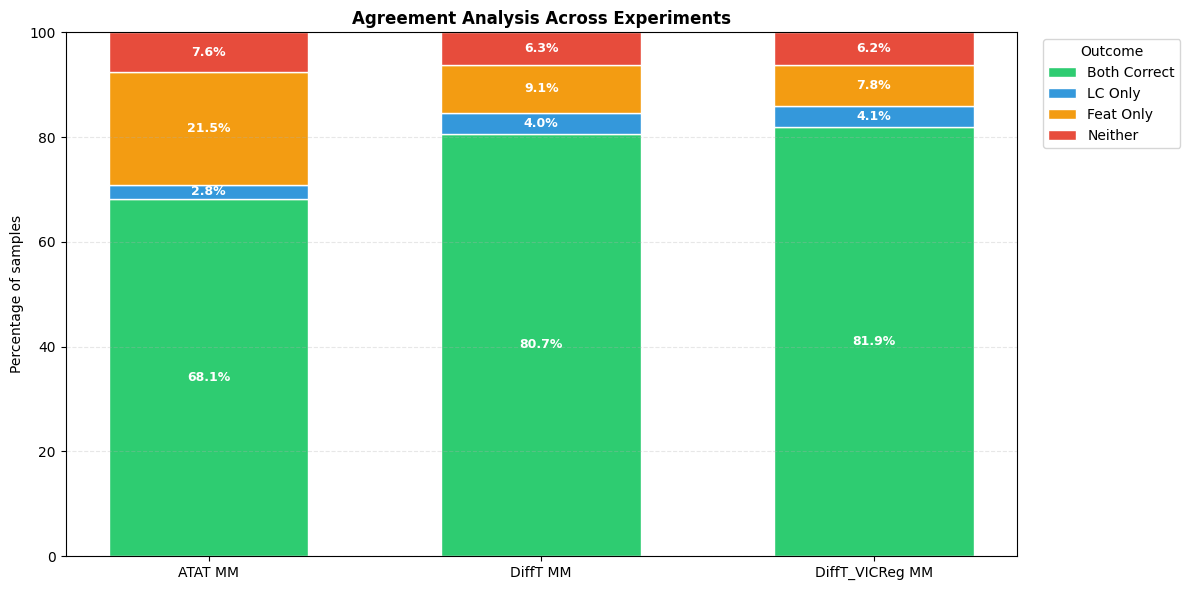

In [8]:
# Analyze all listed experiments and plot stacked bar agreement across them
analysis_results = []
experiment_titles = []
pred_results = []  # Store predictions with OIDs for later analysis

for exp_dict in experiments_mm:
    print(f"Loading experiment: {exp_dict['experiment_name']}")
    predictions = load_multimodal_predictions(exp_dict)

    if predictions and predictions['targets'] is not None:
        analysis = analyze_multimodal_predictions(
            targets=predictions['targets'],
            logits_lcs=predictions['logits_lcs'],
            logits_feat=predictions['logits_feat'],
            logits_mean=predictions['logits_mean'],
        )
        if analysis:
            analysis_results.append(analysis)
            experiment_titles.append(exp_dict['experiment_name'])
            # Store predictions with OIDs for OID-level analysis
            pred_results.append({
                'experiment': exp_dict['experiment_name'],
                'analysis': analysis,
                'oids': predictions['oids'],
                'predictions': predictions
            })
            # Print metrics but skip per-experiment plot to keep a single stacked chart
            print_multimodal_analysis(analysis, title=exp_dict['experiment_name'], show_plot=False)
    else:
        print(f"Skipping {exp_dict['experiment_name']} due to missing predictions.")

if analysis_results:
    plot_agreement_stacked_bars(analysis_results, experiment_titles, use_percentages=True)
else:
    print("No analyses to plot.")


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Loading experiment: DiffT MM
  Loading split 0 (data split: 0)...


Restoring states from the checkpoint path at ../logs/multimodal/DiT_Periodic_MM_2025-10-09_18-22-05/0/checkpoints/epoch_0157.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at ../logs/multimodal/DiT_Periodic_MM_2025-10-09_18-22-05/0/checkpoints/epoch_0157.ckpt


✓ Loaded DiT_Periodic_MM_2025-10-09_18-22-05 (split 0)

DiffT MM
Total Samples: 4569

------------------------------------------------------------
OVERALL ACCURACY
------------------------------------------------------------
LC Modality Accuracy:       84.66%
Feature Modality Accuracy:  89.71%
Mean Logits Accuracy:       91.20%

------------------------------------------------------------
F1 SCORES (Weighted)
------------------------------------------------------------
LC Modality F1:       0.8482
Feature Modality F1:  0.8978
Mean Logits F1:       0.9121

------------------------------------------------------------
AGREEMENT ANALYSIS
------------------------------------------------------------
Both Correct:       3685 ( 80.65%)
LC Only Correct:     183 (  4.01%)
Feat Only Correct:   414 (  9.06%)
Neither Correct:     287 (  6.28%)



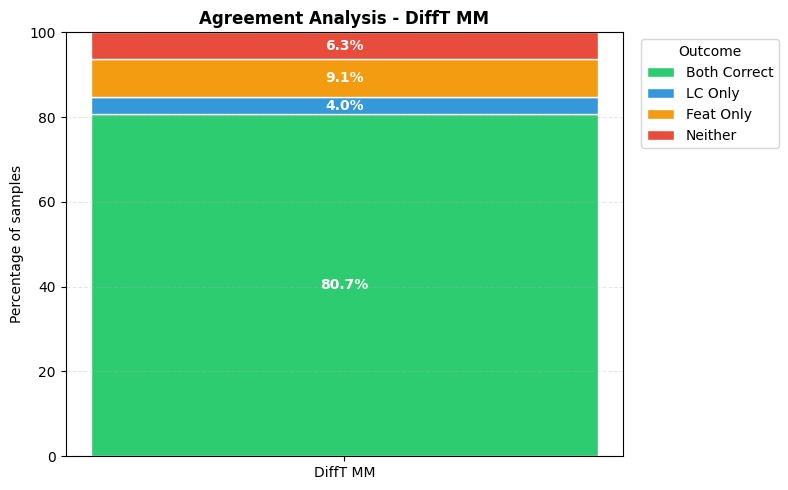

In [9]:
# Example usage: Load and analyze an experiment
exp_dict = experiments_mm[1]  # Select an experiment

print(f"Loading experiment: {exp_dict['experiment_name']}")
predictions = load_multimodal_predictions(exp_dict)

if predictions and predictions['targets'] is not None:
    analysis = analyze_multimodal_predictions(
        targets=predictions['targets'],
        logits_lcs=predictions['logits_lcs'],
        logits_feat=predictions['logits_feat'],
        logits_mean=predictions['logits_mean']
    )
    print_multimodal_analysis(analysis, title=exp_dict['experiment_name'])


Loading experiment: DiffT_VICReg MM


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


  Loading split 0 (data split: 0)...
Loading pre-trained weights from /home/fsoto/Documents/LCsSSL/logs/pre_trained_models/VICReg_dit/1/checkpoints/epoch_0279.ckpt
Checkpoint keys: ['network.transformer_lc.stacked_encoders.0.norm1.weight', 'network.transformer_lc.stacked_encoders.0.norm1.bias', 'network.transformer_lc.stacked_encoders.0.norm2.weight', 'network.transformer_lc.stacked_encoders.0.norm2.bias', 'network.transformer_lc.stacked_encoders.0.attn.qkv_proj.weight']
Model has 55 parameters
Checkpoint has 55 parameters for network
Sample model keys: ['transformer_lc.stacked_encoders.2.norm2.bias', 'transformer_lc.stacked_encoders.1.norm2.weight', 'time_encoder.time_encoders.1.time_diff_emb.0.weight', 'transformer_lc.stacked_encoders.0.attn.qkv_proj.weight', 'time_encoder.time_encoders.0.rate_emb.0.weight']
Sample checkpoint keys: ['transformer_lc.stacked_encoders.2.norm2.bias', 'transformer_lc.stacked_encoders.1.norm2.weight', 'time_encoder.time_encoders.1.time_diff_emb.0.weight', 

Restoring states from the checkpoint path at ../logs/multimodal/DiT_Periodic_VICReg_MM_2025-10-13_07-41-01/0/checkpoints/epoch_0091.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at ../logs/multimodal/DiT_Periodic_VICReg_MM_2025-10-13_07-41-01/0/checkpoints/epoch_0091.ckpt


✓ Loaded DiT_Periodic_VICReg_MM_2025-10-13_07-41-01 (split 0)

DiffT_VICReg MM
Total Samples: 4569

------------------------------------------------------------
OVERALL ACCURACY
------------------------------------------------------------
LC Modality Accuracy:       85.97%
Feature Modality Accuracy:  89.67%
Mean Logits Accuracy:       91.00%

------------------------------------------------------------
F1 SCORES (Weighted)
------------------------------------------------------------
LC Modality F1:       0.8623
Feature Modality F1:  0.8967
Mean Logits F1:       0.9105

------------------------------------------------------------
AGREEMENT ANALYSIS
------------------------------------------------------------
Both Correct:       3740 ( 81.86%)
LC Only Correct:     188 (  4.11%)
Feat Only Correct:   357 (  7.81%)
Neither Correct:     284 (  6.22%)



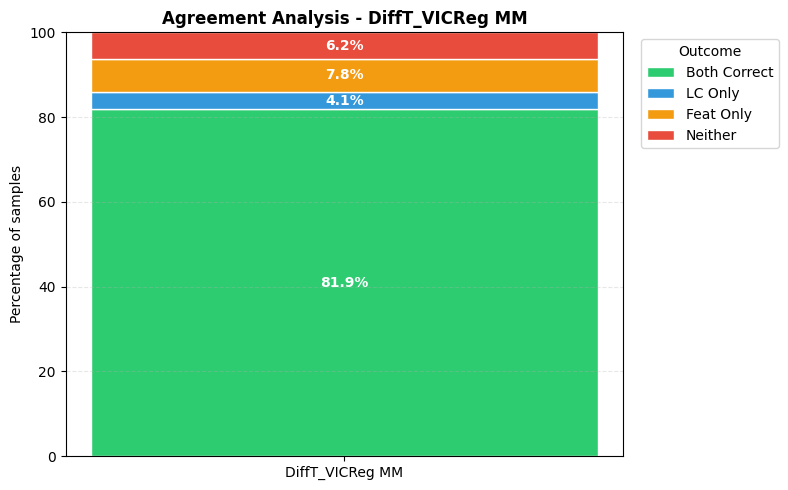

In [10]:
# Example usage: Load and analyze an experiment
exp_dict = experiments_mm[2]  # Select an experiment

print(f"Loading experiment: {exp_dict['experiment_name']}")
predictions = load_multimodal_predictions(exp_dict)

if predictions and predictions['targets'] is not None:
    analysis = analyze_multimodal_predictions(
        targets=predictions['targets'],
        logits_lcs=predictions['logits_lcs'],
        logits_feat=predictions['logits_feat'],
        logits_mean=predictions['logits_mean']
    )
    print_multimodal_analysis(analysis, title=exp_dict['experiment_name'])


In [11]:
exp_result = pred_results[0]
oids = exp_result['oids']

In [12]:
# Example: Plot light curves for incorrect predictions
# First, load the dataset for light curve visualization
import h5py

# Load the H5 dataset
dataset_path = root_dir / "data" / "alerce_data" / "final" / "dataset_full.h5"
print(f"Loading dataset from: {dataset_path}")

if dataset_path.exists():
    h5_dataset = h5py.File(dataset_path, 'r')
    print(f"Dataset loaded successfully. Available keys: {list(h5_dataset.keys())}")
    
    # Now you can plot light curves for samples with incorrect predictions
    if len(pred_results) > 0:
        exp_result = pred_results[0]  # Use first experiment
        analysis = exp_result['analysis']  # Get analysis with categories
        predictions_with_categories = analysis['predictions']  # This has 'category' key
        oids = exp_result['oids']
        
        # If oids from predictions are None, try to get from H5 dataset
        if oids is None and 'SNID' in h5_dataset:
            print("Warning: OIDs not available from model predictions. Using dataset SNIDs instead.")
            snid_list = h5_dataset['SNID'][:]
            oids = snid_list
        
        if oids is not None:
            # Example: Plot light curves for samples where both modalities were wrong
            print(f"\nPlotting incorrect light curves from experiment: {exp_result['experiment']}")
            plot_incorrect_lightcurves_interactive(
                h5_dataset, 
                predictions_with_categories,
                oids, 
                category_filter='neither_correct',
                plots_per_batch=9
            )
            


Loading dataset from: /home/fsoto/Documents/SSLPeriodicLCs/data/alerce_data/final/dataset_full.h5
Dataset loaded successfully. Available keys: ['SNID', 'best_n_periods', 'brightness', 'corrected_period', 'e_brightness', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'extracted_feat_8', 'extracted_feat_None', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'periodic_labels', 'periodic_test', 'periodic_train_0', 'periodic_train_1', 'periodic_train_2', 'periodic_train_3', 'periodic_train_4', 'periodic_valid_0', 'periodic_valid_1', 'periodic_valid_2', 'periodic_valid_3', 'periodic_valid_4', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'training_1', 'training_10', 'training_11', 'training_12', 'training_13', 'training_14', 'training_15', 'training_16', 'training_17', 'training_18', 'training_19', 'training_2', 'training_3', 'training_4', 'tra

Output()